# **Housing Affordability Across 100 Major U.S. Metropolitan Areas**
### Machine Learning and Artificial Intelligence Capstone Project
#### UC Berkeley Professional Certificate in ML / AI
#### Timothy Vermette 
#### August 2026
<br>

Housing affordability has become an increasingly important economic and social issue in the United States. Prospective homebuyers looking to achieve the “American Dream” are faced with increasing and often out-of-reach home prices, as well as navigating household income and broader economic conditions in the area where they live. 

The purpose of this project is to explore how housing affordability has changed across 100 major U.S. metropolitan areas between 2010 and 2024. Using data from Zillow and the U.S. Census Bureau, this analysis examines home values, median household income, population, and educational attainment in 2010, 2015, and 2024.

The goal is to identify which metropolitan areas have become more or less affordable over time, explore the economic factors associated with those differences, and provide prospective homebuyers with a better understanding of how affordability varies across major U.S. housing markets.


## Research Question

How has housing affordability changed across major U.S. metropolitan areas between 2010 and 2024, and what economic and demographic factors are associated with differences in home values and affordability?


## Stakeholder

The primary stakeholder for this analysis is the prospective U.S. homebuyer. The findings are intended to help potential buyers better understand how home prices compare with local incomes, how affordability has changed over time, and which metropolitan areas may offer greater or lesser affordability.


## Scope of This Analysis

This analysis examines 100 major U.S. metropolitan areas using data from 2010, 2015, and 2024. Housing affordability is evaluated primarily using home values relative to median household income, while population and educational attainment are explored as additional factors that may be associated with housing-market differences.

Exploratory data analysis and multiple regression models will be used to examine relationships among these variables and compare housing affordability across metropolitan areas and over time.

### **Data Sources**
#### Zillow:
##### Zillow Home Value Index (ZHVI). URL: https://www.zillow.com/research/data/

#### Census.gov:
##### Median Household Income Past 12 months 2024. URL https://data.census.gov/table/ACSDT1Y2024.B19013?t=Income+(Households,+Families,+Individuals):Income+and+Earnings&g=010XX00US$31000M1&y=2024

##### Median Household Income Past 12 months 2015. URL https://data.census.gov/table/ACSDT5Y2015.B19013?t=Income+(Households,+Families,+Individuals):Income+and+Earnings&g=010XX00US$31000M1&y=2015

##### Median Household Income Past 12 months 2010. URL https://data.census.gov/table/ACSDT5Y2010.B19013?t=Income+(Households,+Families,+Individuals):Income+and+Earnings&g=010XX00US$31000M1&y=2010

##### Total Population 2024 (Metro). URL https://data.census.gov/table/ACSDT5Y2024.B01003?t=Counts,+Estimates,+and+Projections:Population+Total&g=010XX00US$31000M1&y=2024

##### Total Population 2015 (Metro). URL https://data.census.gov/table/ACSDT5Y2015.B01003?t=Counts,+Estimates,+and+Projections:Population+Total&g=010XX00US$31000M1&y=2015

##### Total Population 2010 (Metro). URL https://data.census.gov/table/ACSDT5Y2010.B01003?t=Counts,+Estimates,+and+Projections:Population+Total&g=010XX00US$31000M1&y=2010

##### Educational Attainment for POP over 25 2024. URL https://data.census.gov/table/ACSDT5Y2024.B15003?t=Educational+Attainment&g=010XX00US$31000M1&y=2024

##### Educational Attainment for POP over 25 2015. URL https://data.census.gov/table/ACSDT5Y2015.B15003?t=Educational+Attainment&g=010XX00US$31000M1&y=2015

##### Educational Attainment for POP over 25 2010. URL https://data.census.gov/table/ACSDT1Y2010.B15003?t=Educational+Attainment&g=010XX00US$31000M1&y=2010



## **Data Preparation**
Housing data from Zillow Home Value Index (ZHVI) and demographic data from U.S. Census Bureau American Community Survey (ACS), including median household income, educational attainment, and population were cleaned, standardized, and merged into analytical datasets. 

Metropolitan naming conventions were different between Zillow and Census datasets, therefore a Metro Mapping table was developed to reconcile these differences, and to enable clean merging of multiple datasets based on metropolitan areas. Because Census metro naming conventions also changed over time, historical mappings were created where necessary for the 2010 and 2015 datasets.

Datasets representing the same 100 major U.S. metropolitan areas were created for 2010, 2015, and 2024.

Additional feature engineering was completed to create variables
**"Price to Income Ratio"** calculated by dividing median home value by median household income, to provide a measure of affordability.
**"College Education Percentage"** consisting of percentage of adults 25 years and older that possess a Bachelor's degree or higher.

*This data preparation can be viewed in the additional Jupyter Notebooks titled "Capstone Dataset Exploration" and "Capstone Data Prep".*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_2010 = pd.read_csv('Data Finalized/analysis_2010_top100.csv')
data_2015 = pd.read_csv('Data Finalized/analysis_2015_top100.csv')
data_2024 = pd.read_csv('Data Finalized/final_2024.csv')

In [3]:
print("2010:", data_2010.shape)
print("2015:", data_2015.shape)
print("2024:", data_2024.shape)

print("\n2010 missing:")
print(data_2010.isna().sum())

print("\n2015 missing:")
print(data_2015.isna().sum())

print("\n2024 missing:")
print(data_2024.isna().sum())

2010: (100, 17)
2015: (100, 17)
2024: (100, 9)

2010 missing:
RegionID                  0
SizeRank                  0
RegionName                0
RegionType                0
StateName                 0
Date                      0
HomeValue                 0
Year                      0
Metro                     0
CensusMetro2010           0
CensusMetro_x             0
Income2010                0
CensusMetro_y             0
Population2010            0
CensusMetro               0
CollegeEducatedPct2010    0
PriceToIncomeRatio2010    0
dtype: int64

2015 missing:
RegionID                  0
SizeRank                  0
RegionName                0
RegionType                0
StateName                 0
Date                      0
HomeValue                 0
Year                      0
Metro                     0
CensusMetro2015           0
CensusMetro_x             0
Income2015                0
CensusMetro_y             0
Population2015            0
CensusMetro               0
CollegeEducate

In [4]:
print("2010 columns:")
print(data_2010.columns.tolist())

print("\n2015 columns:")
print(data_2015.columns.tolist())

print("\n2024 columns:")
print(data_2024.columns.tolist())

2010 columns:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'Date', 'HomeValue', 'Year', 'Metro', 'CensusMetro2010', 'CensusMetro_x', 'Income2010', 'CensusMetro_y', 'Population2010', 'CensusMetro', 'CollegeEducatedPct2010', 'PriceToIncomeRatio2010']

2015 columns:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'Date', 'HomeValue', 'Year', 'Metro', 'CensusMetro2015', 'CensusMetro_x', 'Income2015', 'CensusMetro_y', 'Population2015', 'CensusMetro', 'CollegeEducatedPct2015', 'PriceToIncomeRatio2015']

2024 columns:
['RegionID', 'SizeRank', 'Metro', 'StateName', 'HomeValue', 'CollegeEducatedPct', 'Income2024', 'Population2024', 'PriceToIncomeRatio']


In [5]:
# Keeping only variables needed

data_2010_clean = data_2010[
    [
        "Metro",
        "StateName",
        "HomeValue",
        "Income2010",
        "Population2010",
        "CollegeEducatedPct2010",
        "PriceToIncomeRatio2010"
    ]
].copy()

data_2015_clean = data_2015[
    [
        "Metro",
        "StateName",
        "HomeValue",
        "Income2015",
        "Population2015",
        "CollegeEducatedPct2015",
        "PriceToIncomeRatio2015"
    ]
].copy()

data_2024_clean = data_2024[
    [
        "Metro",
        "StateName",
        "HomeValue",
        "Income2024",
        "Population2024",
        "CollegeEducatedPct",
        "PriceToIncomeRatio"
    ]
].copy()

In [6]:
print(data_2010_clean.shape)
print(data_2015_clean.shape)
print(data_2024_clean.shape)

print("\n2010:")
print(data_2010_clean.head())

print("\n2015:")
print(data_2015_clean.head())

print("\n2024:")
print(data_2024_clean.head())

(100, 7)
(100, 7)
(100, 7)

2010:
             Metro StateName      HomeValue  Income2010  Population2010  \
0     New York, NY        NY  392217.115908       63915        18700715   
1  Los Angeles, CA        CA  398666.631278       59876        12723781   
2      Chicago, IL        IL  190206.220312       60574         9384661   
3       Dallas, TX        TX  149304.484387       56349         6154265   
4      Houston, TX        TX  150137.757352       55207         5709313   

   CollegeEducatedPct2010  PriceToIncomeRatio2010  
0               35.964460                6.136543  
1               30.954759                6.658204  
2               33.964616                3.140064  
3               31.114052                2.649639  
4               28.428865                2.719542  

2015:
             Metro StateName      HomeValue  Income2015  Population2015  \
0     New York, NY        NY  428263.745008       67296        19979950   
1  Los Angeles, CA        CA  505439.753601   

In [7]:
# Renaming columns to prepare for concatenation

data_2010_clean = data_2010_clean.rename(columns={
    "Income2010": "Income",
    "Population2010": "Population",
    "CollegeEducatedPct2010": "CollegeEducatedPct",
    "PriceToIncomeRatio2010": "PriceToIncomeRatio"
})
data_2010_clean["Year"] = 2010


data_2015_clean = data_2015_clean.rename(columns={
    "Income2015": "Income",
    "Population2015": "Population",
    "CollegeEducatedPct2015": "CollegeEducatedPct",
    "PriceToIncomeRatio2015": "PriceToIncomeRatio"
})
data_2015_clean["Year"] = 2015


data_2024_clean = data_2024_clean.rename(columns={
    "Income2024": "Income",
    "Population2024": "Population"
})
data_2024_clean["Year"] = 2024

In [8]:
print(data_2010_clean.columns)
print(data_2015_clean.columns)
print(data_2024_clean.columns)

Index(['Metro', 'StateName', 'HomeValue', 'Income', 'Population',
       'CollegeEducatedPct', 'PriceToIncomeRatio', 'Year'],
      dtype='object')
Index(['Metro', 'StateName', 'HomeValue', 'Income', 'Population',
       'CollegeEducatedPct', 'PriceToIncomeRatio', 'Year'],
      dtype='object')
Index(['Metro', 'StateName', 'HomeValue', 'Income', 'Population',
       'CollegeEducatedPct', 'PriceToIncomeRatio', 'Year'],
      dtype='object')


In [9]:
# Combining clean datasets from all 3 years into one Dataframe.

combined_data = pd.concat(
    [data_2010_clean, data_2015_clean, data_2024_clean],
    ignore_index=True
)

print(combined_data.shape)
print(combined_data.isna().sum())

(300, 8)
Metro                 0
StateName             0
HomeValue             0
Income                0
Population            0
CollegeEducatedPct    0
PriceToIncomeRatio    0
Year                  0
dtype: int64


In [10]:
# Confirming that each year contains 100 metros

combined_data["Year"].value_counts().sort_index()

Year
2010    100
2015    100
2024    100
Name: count, dtype: int64

In [11]:
# Saving finalized dataset

combined_data.to_csv(
    "Data Finalized/combined_housing_data.csv",
    index=False
)

## **Exploratory Data Analysis**
With the three datasets cleaned and standardized, the next step is to explore how housing affordability and its related economic and demographic factors changed across U.S. metropolitan areas between 2010, 2015, and 2024.

In [12]:
# Reviewing summary statistics for combined dataset

combined_data.describe()

,HomeValue,Income,Population,CollegeEducatedPct,PriceToIncomeRatio,Year
count,3.000000e+02,300.000000,3.000000e+02,300.000000,300.000000,300.000000
mean,2.778836e+05,65166.073333,2.105024e+06,32.548506,3.999864,2016.333333
std,1.846277e+05,18917.839816,2.681259e+06,7.547189,1.397231,5.802394
min,8.666962e+04,31879.000000,4.612620e+05,15.002311,1.653716,2010.000000
25%,1.565699e+05,50913.000000,7.114595e+05,27.829802,3.061214,2010.000000
50%,2.193609e+05,59897.500000,1.087002e+06,31.868445,3.633836,2015.000000
75%,3.490104e+05,76415.500000,2.295107e+06,36.720963,4.589349,2024.000000
max,1.679506e+06,164801.000000,1.997995e+07,55.463616,10.191114,2024.000000


In [13]:
# Calculating average values across 100 metros for each year

year_summary = combined_data.groupby("Year")[
    ["HomeValue", "Income", "Population", 
     "CollegeEducatedPct", "PriceToIncomeRatio"]
].mean()

year_summary

,HomeValue,Income,Population,CollegeEducatedPct,PriceToIncomeRatio
Year,,,,,
2010,188779.458526,54111.57,1974688.82,29.666887,3.387365
2015,228513.255886,56118.86,2101857.26,31.002855,3.923202
2024,416358.051685,85267.79,2238524.52,36.975776,4.689024


In [14]:
# Calculating percent change in variables of Home Value, Income, and Affordability between 2010 and 2024

home_change = (
    (year_summary.loc[2024, "HomeValue"] -
     year_summary.loc[2010, "HomeValue"])
    / year_summary.loc[2010, "HomeValue"] * 100
)

income_change = (
    (year_summary.loc[2024, "Income"] -
     year_summary.loc[2010, "Income"])
    / year_summary.loc[2010, "Income"] * 100
)

affordability_change = (
    (year_summary.loc[2024, "PriceToIncomeRatio"] -
     year_summary.loc[2010, "PriceToIncomeRatio"])
    / year_summary.loc[2010, "PriceToIncomeRatio"] * 100
)

print(f"Home value change: {home_change:.1f}%")
print(f"Income change: {income_change:.1f}%")
print(f"Price-to-income ratio change: {affordability_change:.1f}%")

Home value change: 120.6%
Income change: 57.6%
Price-to-income ratio change: 38.4%


##### **Initial Finding:**
Between 2010 and 2024, average home values across the 100 metropolitan areas increased by approximately 120.6%, compared with a 57.6% increase in median household income. As a result, the average home price-to-income ratio increased by 38.4%. This suggests that home values substantially outpaced household income growth over the period, contributing to declining housing affordability.

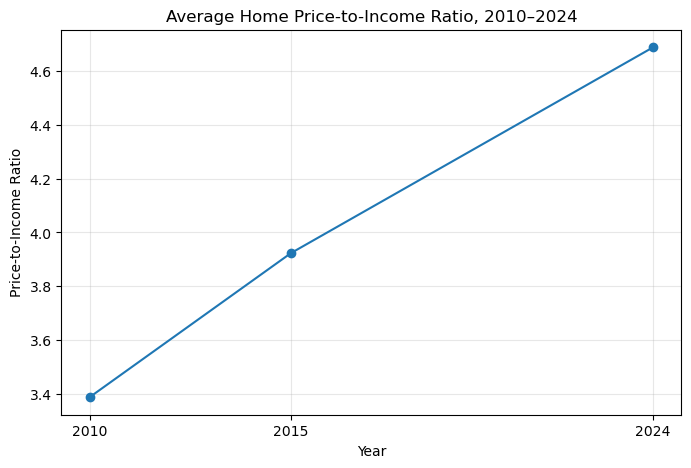

In [15]:
# Plotting the average Price-to-income ratio for 2010, 2015, and 2024

plt.figure(figsize=(8, 5))

plt.plot(
    year_summary.index,
    year_summary["PriceToIncomeRatio"],
    marker="o"
)

plt.title("Average Home Price-to-Income Ratio, 2010–2024")
plt.xlabel("Year")
plt.ylabel("Price-to-Income Ratio")
plt.xticks([2010, 2015, 2024])
plt.grid(alpha=0.3)

plt.show()

##### **Affordability Trend:**
The average home price-to-income ratio increased consistently across the three periods, rising from approximately 3.39 in 2010 to 3.92 in 2015 and 4.69 in 2024. This indicates that home values became increasingly expensive relative to household income across the 100 metropolitan areas studied.

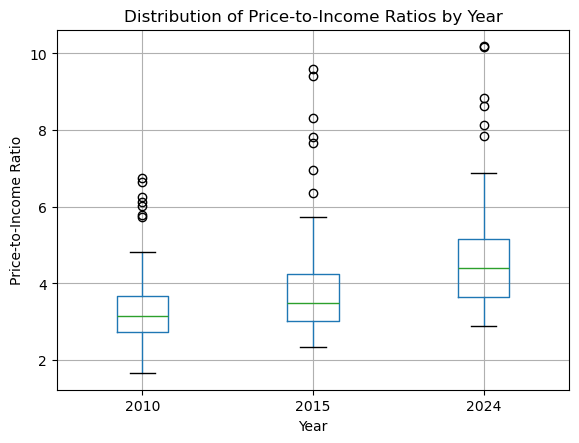

In [16]:
# Plotting comparison of price-to-income ratio distributions for 2010, 2015, 2024

combined_data.boxplot(
    column="PriceToIncomeRatio",
    by="Year"
)

plt.title("Distribution of Price-to-Income Ratios by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Price-to-Income Ratio")

plt.show()

##### **Distribution of Affordability:**
The distribution of price-to-income ratios shifted upward between 2010 and 2024, with the median ratio increasing across each period. The widening distribution and increasingly high outliers also suggest that affordability pressures varied considerably across metropolitan areas, with some markets experiencing substantially greater increases than others.

In [17]:
# Reshaping data to compare average price-to-income ratios across years

affordability_change = combined_data.pivot(
    index="Metro",
    columns="Year",
    values="PriceToIncomeRatio"
)

affordability_change.head()

Year,2010,2015,2024
Metro,,,
"Akron, OH",2.470968,2.432195,3.147172
"Albany, NY",3.600866,3.315462,3.962041
"Albuquerque, NM",3.634974,3.669032,4.520262
"Allentown, PA",3.517928,3.285699,4.137996
"Atlanta, GA",2.541760,3.308902,4.280134


In [18]:
# Creating new columns and calculating change of price-to-income ratios and percent of change between 2010 and 2024

affordability_change["RatioChange"] = (
    affordability_change[2024] - affordability_change[2010]
)

affordability_change["PctChange"] = (
    affordability_change["RatioChange"]
    / affordability_change[2010]
) * 100

In [19]:
# Reviewing top 10 metros with greatest percent change in price-to-income ratio. Our top 10 affordability deterioration metros.

affordability_change.sort_values(
    "PctChange",
    ascending=False
).head(10)

Year,2010,2015,2024,RatioChange,PctChange
Metro,,,,,
"Las Vegas, NV",2.472409,4.072849,5.516416,3.044006,123.119022
"Modesto, CA",2.952015,4.951693,6.003066,3.051051,103.354841
"Detroit, MI",1.653716,2.548328,3.343942,1.690225,102.207683
"Boise City, ID",2.836120,4.003962,5.545618,2.709498,95.535397
"Lakeland, FL",2.431123,3.304951,4.692963,2.261841,93.036880
"Phoenix, AZ",2.684594,4.225589,5.145168,2.460575,91.655374
"Miami, FL",3.216031,4.844740,6.161299,2.945268,91.580819
"Riverside, CA",3.466974,5.437653,6.584186,3.117212,89.911596
"Bakersfield, CA",2.773603,3.888127,5.070713,2.297110,82.820405


In [20]:
# Saving top 10 affordability deterioration for plotting

top10_deterioration = affordability_change.sort_values(
    "PctChange",
    ascending=False
).head(10)

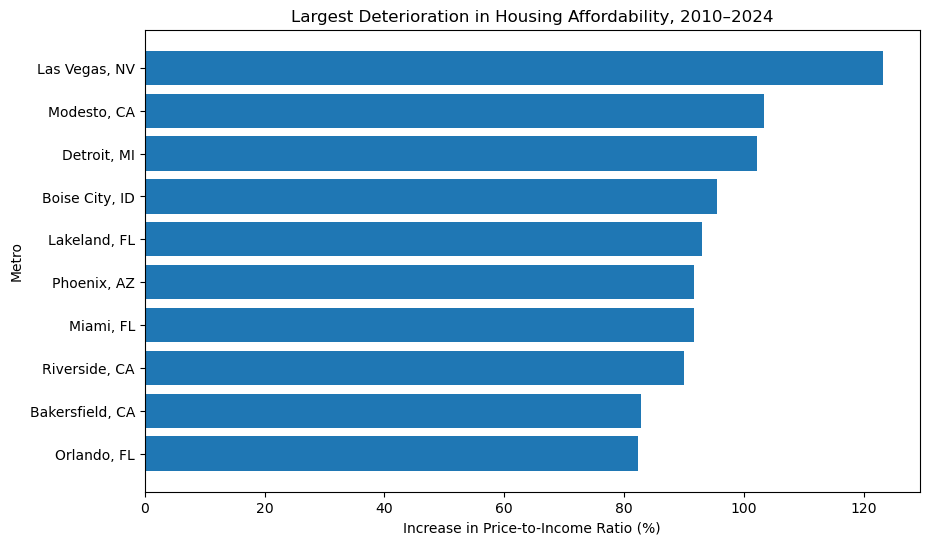

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_deterioration.index,
    top10_deterioration["PctChange"]
)

plt.xlabel("Increase in Price-to-Income Ratio (%)")
plt.ylabel("Metro")
plt.title("Largest Deterioration in Housing Affordability, 2010–2024")

plt.gca().invert_yaxis()
plt.show()

##### **Deterioration of Housing Affordability:**
We see above that housing affordability deteriorated at uneven levels across different metros in the U.S. Between 2010 and 2024, Las Vegas, NV expereinced the largest increase in housing price to income ratio at 123%. We also find increases in several markets spread throughout the country, including several cities in California, Florida, and the Mountain West region. This indicates that the decline in housing affordability has been pronounced in certain regional markets rather than uniformly across the country.

In [22]:
# Reviewing bottom 10 metros in ratio percent change, our improved or most stable metros between 2010 and 2024.

affordability_change.sort_values(
    "PctChange",
    ascending=True
).head(10)

Year,2010,2015,2024,RatioChange,PctChange
Metro,,,,,
"New Orleans, LA",4.392727,4.712377,4.111240,-0.281487,-6.408024
"Baton Rouge, LA",3.730166,3.499622,3.514261,-0.215905,-5.788069
"El Paso, TX",3.665129,3.139893,3.788970,0.123841,3.378907
"Scranton, PA",3.018613,2.734550,3.147283,0.128670,4.262567
"Little Rock, AR",3.081502,3.065669,3.218670,0.137168,4.451319
"Baltimore, MD",3.807360,3.787292,4.017721,0.210361,5.525107
"Pittsburgh, PA",2.686621,2.746623,2.902816,0.216195,8.047082
"Albany, NY",3.600866,3.315462,3.962041,0.361174,10.030211
"St. Louis, MO",2.900062,2.850148,3.233872,0.333810,11.510460


In [23]:
# Saving bottom 10 affordability deterioration (or most stable) for plotting.

bottom10_deterioration = affordability_change.sort_values(
    "PctChange",
    ascending=True
).head(10)

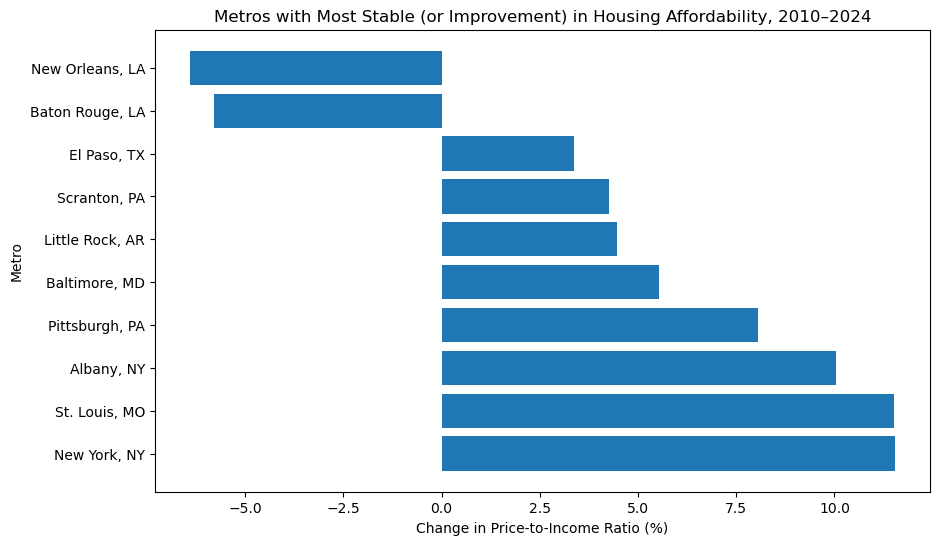

In [24]:
plt.figure(figsize=(10, 6))

plt.barh(
    bottom10_deterioration.index,
    bottom10_deterioration["PctChange"]
)

plt.xlabel("Change in Price-to-Income Ratio (%)")
plt.ylabel("Metro")
plt.title("Metros with Most Stable (or Improvement) in Housing Affordability, 2010–2024")

plt.gca().invert_yaxis()
plt.show()

##### **Summary of Initial Exploratory Data Analysis Findings:**
Our initial EDA findings show a clear decline in housing affordability across the 100 metropolitan areas studied. Between 2010 and 2024, average home values increased by approximately 120.6%, while average household income increased by only 57.6%. As a result, the average price-to-income ratio increased by approximately 38.4%, from 3.39 in 2010 to 4.69 in 2024.

Price-to-income ratios increased across the metros over time as well, indicating that declining housing affordability was widespread, however the magnitude of this change varied across metros. Las Vegas, Modesto, Detroit, Boise City, and Lakeland were among the areas experiencing the greatest percentage deterioration in affordability between 2010 and 2024. In contrast, several metros experienced relatively little change, with New Orleans and Baton Rouge actually showing modest improvements in their price-to-income ratios.

These findings suggest that declining housing affordability is a broad national trend among the 100 metros analyzed, but the deterioration of affordability varies by location. The next stage of this analysis will examine economic factors including income, population, and educational attainment levels, with a goal of understanding whether these factors help to explain these changes.

In [25]:
# Viewing 2024's least affordable metros

least_affordable = (
    data_2024
    .sort_values("PriceToIncomeRatio", ascending=False)
    .head(10)
)

least_affordable[["Metro", "PriceToIncomeRatio"]]

,Metro,PriceToIncomeRatio
34,"San Jose, CA",10.191114
1,"Los Angeles, CA",10.175075
16,"San Diego, CA",8.827001
11,"San Francisco, CA",8.640504
53,"Urban Honolulu, HI",8.128626
69,"Oxnard, CA",7.832872
14,"Seattle, WA",6.872814
0,"New York, NY",6.844117
12,"Riverside, CA",6.584186
7,"Miami, FL",6.161299


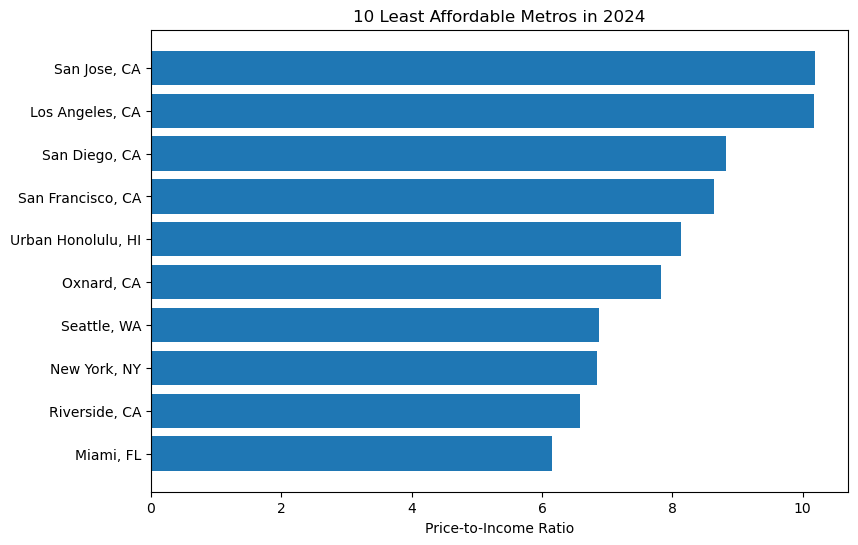

In [26]:
plt.figure(figsize=(9, 6))

plt.barh(
    least_affordable["Metro"],
    least_affordable["PriceToIncomeRatio"]
)

plt.xlabel("Price-to-Income Ratio")
plt.title("10 Least Affordable Metros in 2024")
plt.gca().invert_yaxis()

plt.show()

In [27]:
# Viewing 2024's metros with highest home values

highest_home_values = (
    data_2024
    .sort_values("HomeValue", ascending=False)
    .head(10)
)

highest_home_values[["Metro", "HomeValue"]]

,Metro,HomeValue
34,"San Jose, CA",1.679506e+06
11,"San Francisco, CA",1.171566e+06
1,"Los Angeles, CA",9.809281e+05
16,"San Diego, CA",9.633082e+05
69,"Oxnard, CA",8.948117e+05
53,"Urban Honolulu, HI",8.551721e+05
14,"Seattle, WA",7.724218e+05
9,"Boston, MA",7.221248e+05
0,"New York, NY",6.833988e+05
58,"Bridgeport, CT",6.417051e+05


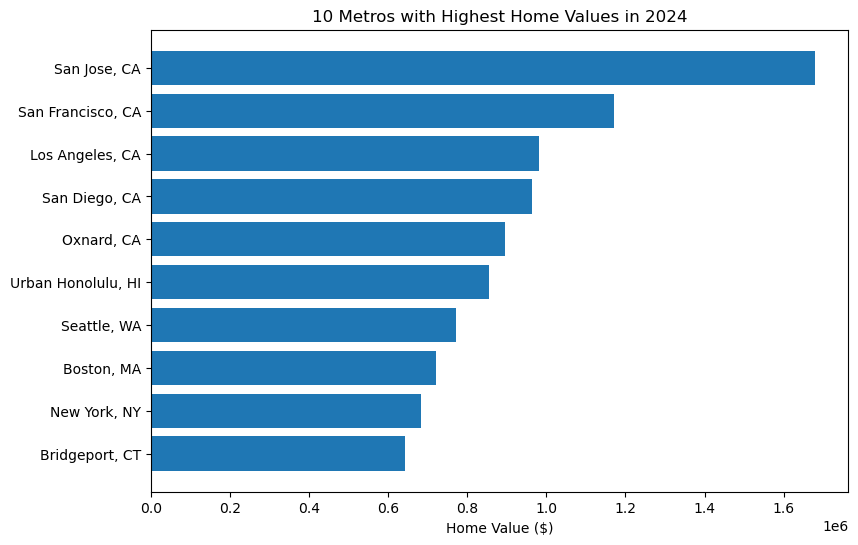

In [28]:
plt.figure(figsize=(9, 6))

plt.barh(
    highest_home_values["Metro"],
    highest_home_values["HomeValue"]
)

plt.xlabel("Home Value ($)")
plt.title("10 Metros with Highest Home Values in 2024")
plt.gca().invert_yaxis()

plt.show()

## **Factors Associated with Changes in Housing Affordability**
The initial EDA showed differences in how housing affordability changed across the 100 metros examined between 2010 and 2024. The next step of this analysis will explore whether changes in economic factors of income, population, and education, are associated with housing affordability.

In [29]:
# Merging 2010 and 2024 data to compare changes over time

change_data = data_2010_clean[
    ["Metro", "Income", "Population", "CollegeEducatedPct", "HomeValue"]
].merge(
    data_2024_clean[
        ["Metro", "Income", "Population", "CollegeEducatedPct", "HomeValue"]
    ],
    on="Metro",
    suffixes=("_2010", "_2024")
)

change_data.head()

,Metro,Income_2010,Population_2010,CollegeEducatedPct_2010,HomeValue_2010,Income_2024,Population_2024,CollegeEducatedPct_2024,HomeValue_2024
0,"New York, NY",63915,18700715,35.964460,392217.115908,99852.0,19798537.0,44.151681,683398.809012
1,"Los Angeles, CA",59876,12723781,30.954759,398666.631278,96405.0,12974487.0,37.970570,980928.090661
2,"Chicago, IL",60574,9384661,33.964616,190206.220312,90770.0,9371595.0,41.598515,331370.219996
3,"Dallas, TX",56349,6154265,31.114052,149304.484387,92733.0,7985590.0,39.386972,385136.186667
4,"Houston, TX",55207,5709313,28.428865,150137.757352,81417.0,7442788.0,36.016343,316340.099352


In [30]:
change_data.shape

(100, 9)

In [31]:
# Calculating percent change in median household income between 2010 and 2024

change_data["IncomePctChange"] = (
    (change_data["Income_2024"] - change_data["Income_2010"])
    / change_data["Income_2010"]
) * 100

change_data[
    ["Metro", "Income_2010", "Income_2024", "IncomePctChange"]
].head()

,Metro,Income_2010,Income_2024,IncomePctChange
0,"New York, NY",63915,99852.0,56.226238
1,"Los Angeles, CA",59876,96405.0,61.007749
2,"Chicago, IL",60574,90770.0,49.849771
3,"Dallas, TX",56349,92733.0,64.569025
4,"Houston, TX",55207,81417.0,47.475864


In [32]:
# Calculating percent change in population from 2010 to 2024

change_data["PopulationPctChange"] = (
    (change_data["Population_2024"] - change_data["Population_2010"])
    / change_data["Population_2010"]
) * 100

change_data[
    ["Metro", "Population_2010", "Population_2024", "PopulationPctChange"]
].head()

,Metro,Population_2010,Population_2024,PopulationPctChange
0,"New York, NY",18700715,19798537.0,5.870481
1,"Los Angeles, CA",12723781,12974487.0,1.970373
2,"Chicago, IL",9384661,9371595.0,-0.139227
3,"Dallas, TX",6154265,7985590.0,29.757006
4,"Houston, TX",5709313,7442788.0,30.362234


In [33]:
# Calculating percent change in Education from 2010 to 2024

change_data["EducationChange"] = (
    change_data["CollegeEducatedPct_2024"]
    - change_data["CollegeEducatedPct_2010"]
)

change_data[
    ["Metro", "CollegeEducatedPct_2010",
     "CollegeEducatedPct_2024", "EducationChange"]
].head()

,Metro,CollegeEducatedPct_2010,CollegeEducatedPct_2024,EducationChange
0,"New York, NY",35.964460,44.151681,8.187221
1,"Los Angeles, CA",30.954759,37.970570,7.015811
2,"Chicago, IL",33.964616,41.598515,7.633899
3,"Dallas, TX",31.114052,39.386972,8.272920
4,"Houston, TX",28.428865,36.016343,7.587478


In [34]:
# Calculating percent change in home values between 2010 and 2024

change_data["HomeValuePctChange"] = (
    (change_data["HomeValue_2024"] - change_data["HomeValue_2010"])
    / change_data["HomeValue_2010"]
) * 100

change_data[
    ["Metro", "HomeValue_2010", "HomeValue_2024", "HomeValuePctChange"]
].head()

,Metro,HomeValue_2010,HomeValue_2024,HomeValuePctChange
0,"New York, NY",392217.115908,683398.809012,74.239925
1,"Los Angeles, CA",398666.631278,980928.090661,146.052218
2,"Chicago, IL",190206.220312,331370.219996,74.216290
3,"Dallas, TX",149304.484387,385136.186667,157.953529
4,"Houston, TX",150137.757352,316340.099352,110.699897


In [35]:
# Calculating price-to-income ratios for 2010 and 2024, and the percent change of price-to-income between 2010 and 2024.

change_data["PriceToIncome_2010"] = (
    change_data["HomeValue_2010"] / change_data["Income_2010"]
)

change_data["PriceToIncome_2024"] = (
    change_data["HomeValue_2024"] / change_data["Income_2024"]
)

change_data["AffordabilityPctChange"] = (
    (change_data["PriceToIncome_2024"] - change_data["PriceToIncome_2010"])
    / change_data["PriceToIncome_2010"]
) * 100

In [36]:
change_data[
    ["Metro",
     "IncomePctChange",
     "PopulationPctChange",
     "EducationChange",
     "HomeValuePctChange",
     "AffordabilityPctChange"]
].head(10)

,Metro,IncomePctChange,PopulationPctChange,EducationChange,HomeValuePctChange,AffordabilityPctChange
0,"New York, NY",56.226238,5.870481,8.187221,74.239925,11.530513
1,"Los Angeles, CA",61.007749,1.970373,7.015811,146.052218,52.820109
2,"Chicago, IL",49.849771,-0.139227,7.633899,74.216290,16.260632
3,"Dallas, TX",64.569025,29.757006,8.272920,157.953529,56.744885
4,"Houston, TX",47.475864,30.362234,7.587478,110.699897,42.870766
5,"Washington, DC",47.378006,16.646436,7.574651,79.774231,21.981723
6,"Philadelphia, PA",50.765861,6.096043,9.074107,73.406934,15.017374
7,"Miami, FL",65.083233,14.061698,8.550554,216.267809,91.580819
8,"Atlanta, GA",60.458732,22.072957,8.037693,170.200541,68.392545
9,"Boston, MA",68.362317,10.338119,8.941463,113.733570,26.948580


In [37]:
# Reviewing summary of change_data dataframe

change_data[
    ["IncomePctChange",
     "PopulationPctChange",
     "EducationChange",
     "HomeValuePctChange",
     "AffordabilityPctChange"]
].describe()

,IncomePctChange,PopulationPctChange,EducationChange,HomeValuePctChange,AffordabilityPctChange
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,57.498970,15.877102,7.308889,121.408609,40.038207
std,11.286055,15.831374,2.042723,47.641891,26.074374
min,30.906458,-33.394888,0.184837,22.517940,-6.408024
25%,48.970344,6.197099,6.234668,86.839090,22.536594
50%,55.333337,13.413844,7.477503,112.695259,35.403816
75%,64.853532,24.038751,8.694732,157.191755,53.159988
max,90.993904,64.059581,11.556503,240.072396,123.119022


In [38]:
# Confirming no missing values

change_data[
    ["IncomePctChange",
     "PopulationPctChange",
     "EducationChange",
     "HomeValuePctChange",
     "AffordabilityPctChange"]
].isna().sum()

IncomePctChange           0
PopulationPctChange       0
EducationChange           0
HomeValuePctChange        0
AffordabilityPctChange    0
dtype: int64

In [39]:
# Reviewing correlations between percent change variables

corr = change_data[
    ["IncomePctChange",
     "PopulationPctChange",
     "EducationChange",
     "HomeValuePctChange",
     "AffordabilityPctChange"]
].corr()

corr

,IncomePctChange,PopulationPctChange,EducationChange,HomeValuePctChange,AffordabilityPctChange
IncomePctChange,1.000000,0.475041,0.429910,0.581029,0.291718
PopulationPctChange,0.475041,1.000000,0.221562,0.454183,0.354338
EducationChange,0.429910,0.221562,1.000000,0.166966,0.022261
HomeValuePctChange,0.581029,0.454183,0.166966,1.000000,0.945874
AffordabilityPctChange,0.291718,0.354338,0.022261,0.945874,1.000000


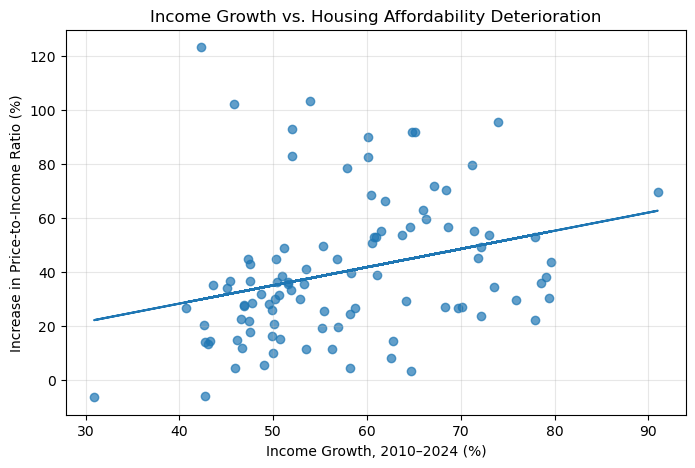

In [40]:
# Visualizing Income Growth and Price to Income Ratio

plt.figure(figsize=(8, 5))

plt.scatter(
    change_data["IncomePctChange"],
    change_data["AffordabilityPctChange"],
    alpha=0.7
)

m, b = np.polyfit(
    change_data["IncomePctChange"],
    change_data["AffordabilityPctChange"],
    1
)

plt.plot(
    change_data["IncomePctChange"],
    m * change_data["IncomePctChange"] + b
)

plt.xlabel("Income Growth, 2010–2024 (%)")
plt.ylabel("Increase in Price-to-Income Ratio (%)")
plt.title("Income Growth vs. Housing Affordability Deterioration")

plt.grid(alpha=0.3)
plt.show()

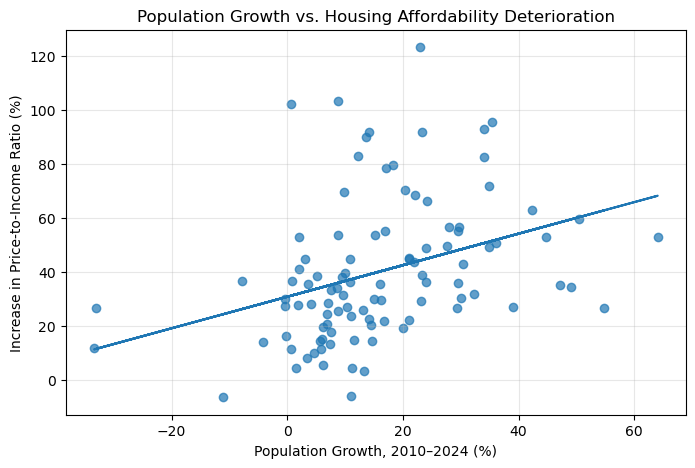

In [41]:
# Visualizing Population Growth and Price to Income Ratio

plt.figure(figsize=(8, 5))

plt.scatter(
    change_data["PopulationPctChange"],
    change_data["AffordabilityPctChange"],
    alpha=0.7
)

m, b = np.polyfit(
    change_data["PopulationPctChange"],
    change_data["AffordabilityPctChange"],
    1
)

plt.plot(
    change_data["PopulationPctChange"],
    m * change_data["PopulationPctChange"] + b
)

plt.xlabel("Population Growth, 2010–2024 (%)")
plt.ylabel("Increase in Price-to-Income Ratio (%)")
plt.title("Population Growth vs. Housing Affordability Deterioration")

plt.grid(alpha=0.3)
plt.show()

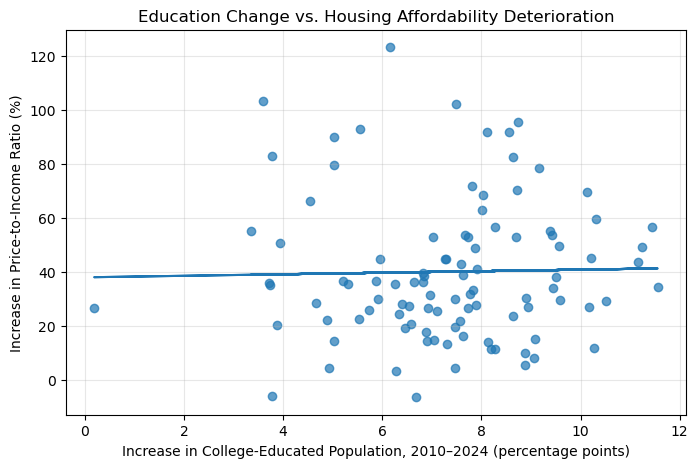

In [42]:
# Visualizing Education Attainment (percent change) compared to Price to Income Ratio

plt.figure(figsize=(8, 5))

plt.scatter(
    change_data["EducationChange"],
    change_data["AffordabilityPctChange"],
    alpha=0.7
)

m, b = np.polyfit(
    change_data["EducationChange"],
    change_data["AffordabilityPctChange"],
    1
)

plt.plot(
    change_data["EducationChange"],
    m * change_data["EducationChange"] + b
)

plt.xlabel("Increase in College-Educated Population, 2010–2024 (percentage points)")
plt.ylabel("Increase in Price-to-Income Ratio (%)")
plt.title("Education Change vs. Housing Affordability Deterioration")

plt.grid(alpha=0.3)
plt.show()

In [43]:
# Top 10 population growth metros

population_growth = (
    change_data
    .sort_values("PopulationPctChange", ascending=False)
    .head(10)
)

population_growth[["Metro", "PopulationPctChange"]]

,Metro,PopulationPctChange
22,"Charlotte, NC",64.059581
59,"Greenville, SC",54.830304
51,"Grand Rapids, MI",50.416828
28,"Austin, TX",49.092851
85,"Winston, NC",47.096106
88,"Provo, UT",44.778009
86,"Deltona, FL",42.353740
41,"Raleigh, NC",39.039950
63,"Knoxville, TN",36.027052
76,"Boise City, ID",35.472584


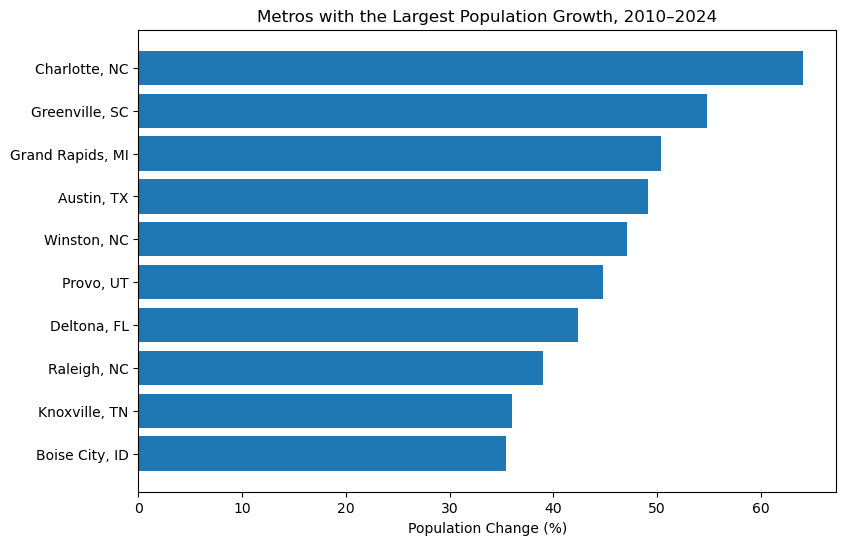

In [44]:
# Visualizing top 10 population growth metros

plt.figure(figsize=(9, 6))

plt.barh(
    population_growth["Metro"],
    population_growth["PopulationPctChange"]
)

plt.xlabel("Population Change (%)")
plt.title("Metros with the Largest Population Growth, 2010–2024")
plt.gca().invert_yaxis()

plt.show()

In [45]:
# Bottom 10 population growth metros / population declines

population_decline = (
    change_data
    .sort_values("PopulationPctChange", ascending=True)
    .head(10)
)

population_decline[["Metro", "PopulationPctChange"]]

,Metro,PopulationPctChange
66,"New Haven, CT",-33.394888
82,"Springfield, MA",-33.033964
45,"New Orleans, LA",-11.163418
89,"Toledo, OH",-7.852520
47,"Hartford, CT",-4.212496
80,"Akron, OH",-0.465515
87,"Syracuse, NY",-0.364444
2,"Chicago, IL",-0.139227
20,"St. Louis, MO",0.664002
13,"Detroit, MI",0.709852


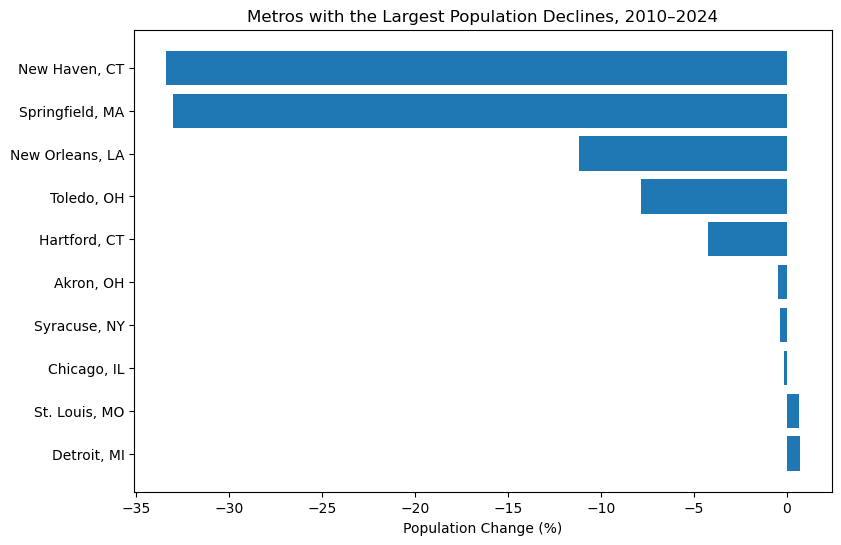

In [46]:
# Visualizing metros with largest population declines

plt.figure(figsize=(9, 6))

plt.barh(
    population_decline["Metro"],
    population_decline["PopulationPctChange"]
)

plt.xlabel("Population Change (%)")
plt.title("Metros with the Largest Population Declines, 2010–2024")

plt.gca().invert_yaxis()

plt.show()

##### **Factors Associated with Changes in Housing Affordability, Initial Findings:**
The first step of this section was to calculate the percentage change in median household income, population, college-educated residents, and home values from 2010 to 2024 across the 100 metros under examination. These measures were then compared with the percentage change in the price-to-income ratio for each metro, which represents deterioration in housing affordability.

The correlation table and scatterplots show different relationships between these factors and affordability. Population growth showed the strongest relationship of the three factors, suggesting that metros with increasing populations tended to experience greater deterioration in housing affordability. Income growth had the next highest correlation with affordability deterioration. This relationship was positive, but weaker, which is interesting since higher income growth might be expected to improve affordability. However, our earlier findings showed that home values increased substantially faster than incomes overall. Educational attainment showed virtually no linear relationship with changes in housing affordability.

Home value growth, not surprisingly, showed a very strong relationship with affordability deterioration, suggesting that increases in home prices were closely associated with increases in the price-to-income ratio.

## **Modeling: Housing Affordability Deterioration**
The following models examine whether changes in income, population, and educational attainment can help predict differences in housing affordability deterioration across metropolitan areas from 2010 to 2024. Multiple regression models will be evaluated using a train/test split, cross-validation, RMSE, and R². Hyperparameter tuning will also be used where appropriate to compare model performance.

### Defining Features and Target
For the predictive modeling stage, the target variable (y) is the percentage change in the price-to-income ratio from 2010 to 2024, representing the deterioration in housing affordability for each metro. The features (X) include changes in median household income, population, and educational attainment over the same period. Home value change is excluded as a predictor because home value is already used to calculate the price-to-income ratio.

In [47]:
X = change_data[
    ["IncomePctChange",
     "PopulationPctChange",
     "EducationChange"]
]

y = change_data["AffordabilityPctChange"]

In [48]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (100, 3)
y shape: (100,)


,IncomePctChange,PopulationPctChange,EducationChange
0,56.226238,5.870481,8.187221
1,61.007749,1.970373,7.015811
2,49.849771,-0.139227,7.633899
3,64.569025,29.757006,8.272920
4,47.475864,30.362234,7.587478


### Evaluation Metrics
RMSE (Root Mean Squared Error) will be used as the primary evaluation metric for comparing model performance. Lower RMSE indicates better model performance, since RMSE measures the typical size of prediction errors. Our target is percentage change in the price-to-income ratio, and RMSE will also be measured in percentage units. R² will also be reported to show how much of the variation in housing affordability deterioration is explained by each model.

In [49]:
# Splitting data into 80% training and 20% test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 3)
X_test shape: (20, 3)
y_train shape: (80,)
y_test shape: (20,)


### Baseline Linear Regression

In [50]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
y_pred = linear_model.predict(X_test)

In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R²:", r2)

Test RMSE: 21.188093796843795
Test R²: 0.33826205985247737


In [53]:
# Extracting coefficients to examine relationship with affordability change

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,IncomePctChange,0.286949
1,PopulationPctChange,0.428386
2,EducationChange,-1.122184


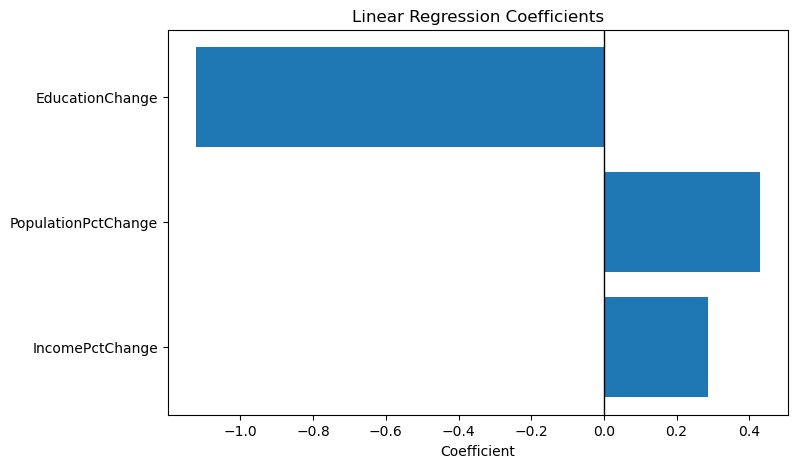

In [54]:
# Visualizing coefficients

plt.figure(figsize=(8, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient")
plt.title("Linear Regression Coefficients")
plt.show()

### Cross-Validation of Baseline Linear Regression

To evaluate whether the baseline linear regression model performs consistently across different subsets of the data, 5-fold cross-validation was performed. This provides a more reliable estimate of model performance than relying solely on a single train/test split.

In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("Cross-Validation RMSE:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())
print("CV RMSE Standard Deviation:", cv_rmse.std())

Cross-Validation RMSE: [29.59519685 25.14670317 16.20577105 26.58280701 23.6330228 ]
Mean CV RMSE: 24.23270017591252
CV RMSE Standard Deviation: 4.470033072234901


#### Baseline Model Evaluation:
The baseline linear regression produced a test RMSE of 21.19 and an R² of 0.338, indicating that the model explained approximately 34% of the variation in housing affordability deterioration within the test data. Five-fold cross-validation produced a mean RMSE of 24.23 with a standard deviation of 4.47. The variation across folds suggests that model performance depends somewhat on which metros are used for testing, while the cross-validation average provides a more robust estimate of expected prediction error.

### Ridge Regression with Hyperparameter Tuning

Ridge regression will be used as an alternative to the baseline linear regression model. GridSearchCV will test different values of the regularization parameter alpha and identify the value that produces the best cross-validated performance.

In [56]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

In [57]:
grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,100


In [58]:
print("Best alpha:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Best alpha: {'alpha': 100}
Best CV RMSE: 25.215695892303124


In [59]:
best_ridge = grid_search.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(
    y_test, ridge_pred
)

print("Ridge Test RMSE:", ridge_rmse)
print("Ridge Test R²:", ridge_r2)

Ridge Test RMSE: 21.337958091318775
Ridge Test R²: 0.3288679529115409


In [60]:
# Expanding alpha range since GridSearch CV selected the highest alpha of 100

param_grid = {
    "alpha": [100, 500, 1000, 5000, 10000]
}

grid_search_expanded = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_search_expanded.fit(X_train, y_train)

print("Best alpha:", grid_search_expanded.best_params_)
print("Best CV RMSE:", -grid_search_expanded.best_score_)

Best alpha: {'alpha': 10000}
Best CV RMSE: 24.796044332749897


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Scaling features before Ridge Regression 

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000, 10000]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_grid.fit(X_train, y_train)

print("Best alpha:", ridge_grid.best_params_)
print("Best CV RMSE:", -ridge_grid.best_score_)

Best alpha: {'ridge__alpha': 100}
Best CV RMSE: 24.96900788853788


In [62]:
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Test RMSE:", ridge_rmse)
print("Ridge Test R²:", ridge_r2)

Ridge Test RMSE: 23.429042008912962
Ridge Test R²: 0.19088300430638327


#### Ridge Regression Results:
GridSearchCV selected a best alpha of 100 after testing multiple alphas. The tuned Ridge model produced a Root Mean Squared Error of 23.43, and a Ridge Test R² of 0.19. Our baseline Linear Regression model outperformed Ridge with RMSE of 21.19 and R² of 0.34. Cross Validation scores were also higher with Ridge than our baseline model (24.97 vs. 24.23), meaning our baseline model outperformed Ridge in this area as well.

### Decision Tree Regression

A Decision Tree Regressor will be used to explore whether nonlinear relationships between income growth, population growth, and educational attainment can better predict changes in housing affordability. GridSearchCV will be used to tune the model and reduce the risk of overfitting.

In [63]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [64]:
tree_grid = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

tree_grid.fit(X_train, y_train)

print("Best parameters:", tree_grid.best_params_)
print("Best CV RMSE:", -tree_grid.best_score_)

Best parameters: {'max_depth': 2, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV RMSE: 28.994709160838266


In [65]:
best_tree = tree_grid.best_estimator_

tree_pred = best_tree.predict(X_test)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Test RMSE:", tree_rmse)
print("Decision Tree Test R²:", tree_r2)

Decision Tree Test RMSE: 22.20346147366312
Decision Tree Test R²: 0.27331928931055816


In [66]:
tree_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree.feature_importances_
})

tree_importance = tree_importance.sort_values(
    "Importance",
    ascending=False
)

tree_importance

,Feature,Importance
1,PopulationPctChange,0.64464
0,IncomePctChange,0.35536
2,EducationChange,0.00000


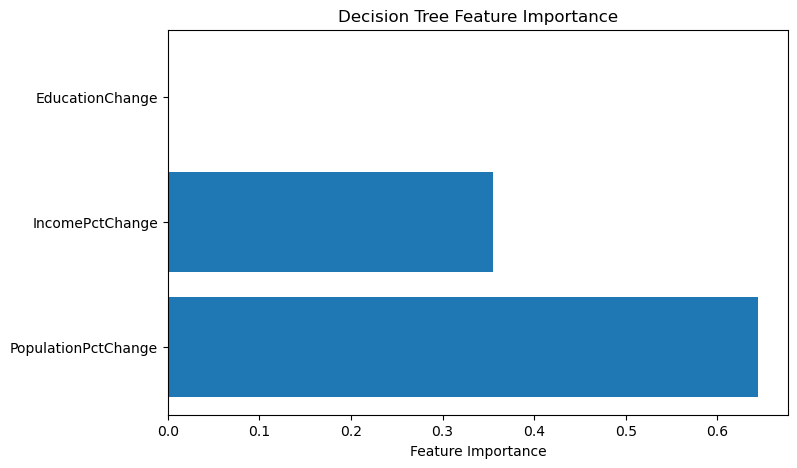

In [67]:
plt.figure(figsize=(8, 5))

plt.barh(
    tree_importance["Feature"],
    tree_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.show()

#### Decision Tree Regression Results:
GridSearchCV selected Decision Tree max depth of 2, minimum samples leaf of 4, and minimum samples split of 2. The tuned model produced a Test RMSE of 22.2 and a R² of 0.27. It's best Cross Validation RMSE was 28.99. Decision Tree performed better than Ridge on test set, but it still did not outperform Linear Regression. Feature importance from Decision Tree shows that Population is the strongest feature at 64%, followed by income at 36%. Education was not used by the tuned Decision Tree. These feature importance results are in alignment with our initial findings during EDA. 

### Random Forest Regression

A Random Forest Regressor will be used to determine whether combining multiple decision trees can improve prediction of housing affordability deterioration. GridSearchCV will be used to tune the model and evaluate its cross-validated performance.

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 5, None],
    "min_samples_leaf": [1, 2, 4]
}

In [69]:
forest_grid = GridSearchCV(
    forest,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

forest_grid.fit(X_train, y_train)

print("Best parameters:", forest_grid.best_params_)
print("Best CV RMSE:", -forest_grid.best_score_)

Best parameters: {'max_depth': 2, 'min_samples_leaf': 4, 'n_estimators': 50}
Best CV RMSE: 25.908145636950962


In [70]:
best_forest = forest_grid.best_estimator_

forest_pred = best_forest.predict(X_test)

forest_rmse = np.sqrt(
    mean_squared_error(y_test, forest_pred)
)

forest_r2 = r2_score(y_test, forest_pred)

print("Random Forest Test RMSE:", forest_rmse)
print("Random Forest Test R²:", forest_r2)

Random Forest Test RMSE: 20.275960269001317
Random Forest Test R²: 0.39401046445500854


In [71]:
forest_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_forest.feature_importances_
})

forest_importance = forest_importance.sort_values(
    "Importance",
    ascending=False
)

forest_importance

,Feature,Importance
1,PopulationPctChange,0.637267
0,IncomePctChange,0.234273
2,EducationChange,0.128460


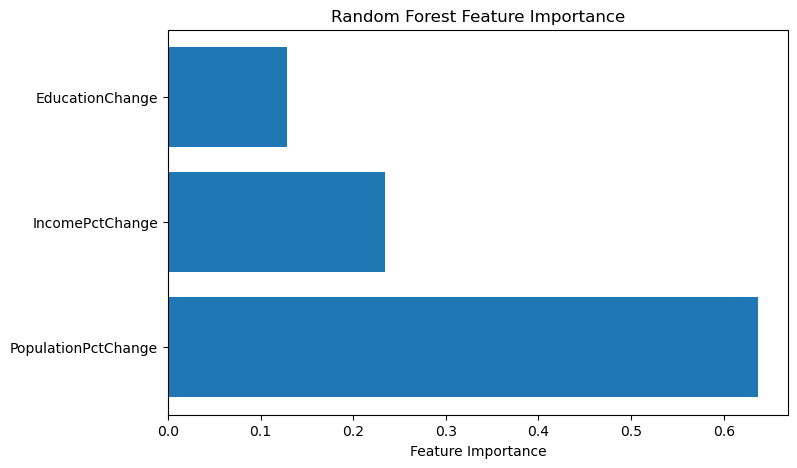

In [72]:
plt.figure(figsize=(8, 5))

plt.barh(
    forest_importance["Feature"],
    forest_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

#### Random Forest Regression Results:
GridSearchCV selected a max depth of 2, min samples leaf of 4, and n estimators of 50. The tuned Random Forest produced a Test RMSE of 20.28 and R² of 0.39. This is the first model that outperformed our baseline Linear Regression model on the test set. Random Forest's CV RMSE was 25.91, which was slightly higher than Linear Regression's 24.23.
Feature importance from Random Forest continues to support our initial EDA findings, identifying population as the strongest predictor at 64%, followed by income as the second strongest predictor at 23%. Education importance was higher with Random Forest, at 13%.

## Model Comparison

The performance of each regression model is compared using Test RMSE, Test R², and cross-validation RMSE. Lower RMSE indicates better predictive performance, while higher R² indicates that the model explains more of the variation in housing affordability deterioration.

In [73]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Test RMSE": [
        rmse,
        ridge_rmse,
        tree_rmse,
        forest_rmse
    ],
    
    "Test R²": [
        r2,
        ridge_r2,
        tree_r2,
        forest_r2
    ],
    
    "CV RMSE": [
        cv_rmse.mean(),
        -ridge_grid.best_score_,
        -tree_grid.best_score_,
        -forest_grid.best_score_
    ]
})

model_comparison.round(2)

,Model,Test RMSE,Test R²,CV RMSE
0,Linear Regression,21.19,0.34,24.23
1,Ridge Regression,23.43,0.19,24.97
2,Decision Tree,22.20,0.27,28.99
3,Random Forest,20.28,0.39,25.91


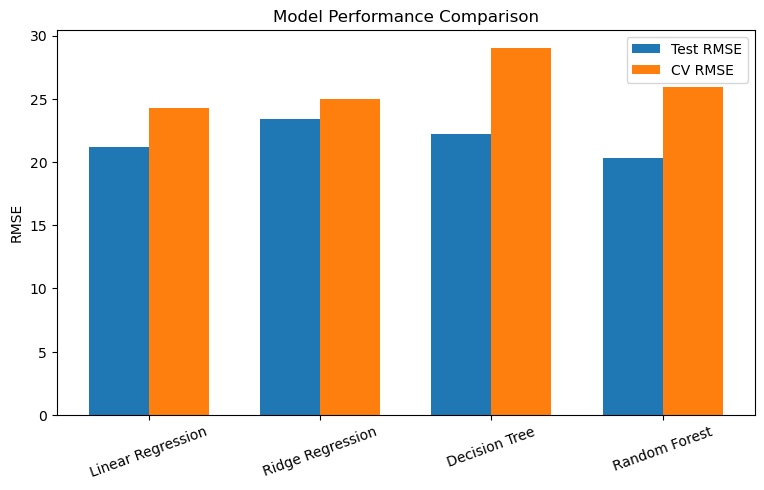

In [74]:
# Visualizing model performance comparison with test RMSE and CV RMSE

x = np.arange(len(model_comparison))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    model_comparison["Test RMSE"],
    width,
    label="Test RMSE"
)

plt.bar(
    x + width/2,
    model_comparison["CV RMSE"],
    width,
    label="CV RMSE"
)

plt.xticks(
    x,
    model_comparison["Model"],
    rotation=20
)

plt.ylabel("RMSE")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

#### Model Comparison
Random Forest produced the lowest Test RMSE of 20.28 and the highest Test R² of 0.39, slightly outperforming the baseline Linear Regression model on the test set. However, Linear Regression produced the lowest Cross-Validation RMSE of 24.23, compared with 25.91 for Random Forest. Ridge Regression and Decision Tree did not improve upon the baseline overall. These results suggest that Random Forest may capture some nonlinear relationships in the data, while Linear Regression showed more consistent performance across cross-validation.

## **Conclusion and Key Findings**
Housing affordability across the top 100 U.S. metros examined has changed considerably over the last 15 years. Based on the affordability feature engineered for this project, "price-to-income ratio," which divides typical home values by median household income, we have found that on average, this ratio increased from approximately 3.39 in 2010 to 3.92 in 2015 and 4.69 in 2024. The data also showed that this increase varied widely across metros and regions. In fact, there were 2 metros, New Orleans, LA, and Baton Rouge, LA, that experienced an improvement in affordability. All other metros examined experienced a deterioration in affordability. 

The top 10 metros with the greatest deterioration in affordability are spread across the country, and the percent increase in price-to-income ratio ranges from 82% to 123%. 3 of these top 10 metros are in California, 3 are in Florida, Las Vegas leads the pack, and Detroit, Boise City, and Phoenix complete this top 10 affordability deterioration list. 


Our top 5 most unaffordable metros have a price-to-income ratio greater than 8. 4 of these 5 metros are in California, and the top 2 (San Francisco and Los Angeles) have a ratio greater than 10.

High home values do not necessarily equate to deterioration in affordability. For example, New York ranks 8th in highest home values, but also made the top 10 for most stable in terms of affordability, with only an 11.5% price-to-income ratio increase.

Population growth showed the strongest association with deterioration in affordability. However, this relationship was not one-to-one. Boise City was the only metro that made the top 10 in population growth as well as top 10 in affordability deterioration. All other metros that topped the list for population growth did not make the top 10 for affordability deterioration. This suggests that population growth may be an important factor, but other factors also contribute to affordability. On the flip side, the only metro with a population decline and improvement in affordability is New Orleans. These findings show association and do not establish causation.

Income was our second strongest factor associated with deterioration of affordability. Education showed a weaker relationship.


The modeling results were generally aligned with our initial EDA findings. Random Forest performed best on the test set, while Linear Regression performed better across Cross-Validation. Population, in both EDA and modeling, was shown to be the strongest predictor of change in price-to-income ratio, followed by income. Education was a less important factor in predicting the target. Overall, our models were able to explain some of the variation in housing affordability deterioration across our selected 100 metros, but the results also suggest that there are other important factors not explored in this project. 

## **Stakeholder Recommendations**
For prospective homebuyers in the U.S., these findings can help to shape perspective when it comes to comparing home values across metros and/or embarking on the journey of selecting a city to plant roots. Home valuation alone, while extremely important, does not tell the whole story. It is important to explore how affordability has changed over time and understand the relationship between income and home values. Additionally, obtaining an understanding of population ebbs and flows in different metros may provide additional context when evaluating housing markets. While it is of utmost importance to choose to live in an area that is affordable, it can also be valuable to understand how affordability has changed over time. Depending on one's budget and income, high home valuations do not immediately indicate that a metro is unaffordable, just as current affordability does not necessarily indicate how affordability will change over time.

For local governments, housing organizations, developers, and community planners, the results suggest that population growth should be considered when evaluating future housing needs. Population growth showed the strongest association with deterioration in affordability in this analysis, although the relationship was not one-to-one. Rapidly growing metros may benefit from closer examination of whether housing availability is keeping pace with population growth, along with income trends and other local economic conditions.

## **Limitations and Future Work**

### Limitations
While this project explored factors most associated with housing affordability, I only explored the top 100 metropolitan areas in the U.S. based on Zillow's metro rankings. It is possible that the incorporation of additional metros would yield different results. I chose to use a select few variables from U.S. Census Bureau datasets, including Median Household Income, Population, and Educational Attainment, as these were the most interesting to me. It is possible and likely that selecting and utilizing additional or different variables would yield different results. Our analysis also only spanned the last 15 years, as 2010 was the oldest year used from the U.S. Census Bureau data. Finally, our models identified associations between variables and affordability, but did not establish causation of affordability changes. This would require a much more in-depth economic exploration.

### Future Work
In order to expand on this analysis and potentially improve predictions of housing affordability in the U.S., additional variables could be incorporated. Rather than gauging trends using only 2010, 2015, and 2024, a future analysis could also examine changes on a year-over-year basis. Additional variables that would be useful to explore include mortgage rates over time, employment and unemployment rates across metros, housing supply and new construction, property taxes, and local housing policies. With more detailed annual data, future modeling could also explore whether these historical trends can help predict which metros may experience greater affordability challenges in the next five years.